# (26) Kyoto16, gaussian-sigmoid: (16, 24.0)

project = ```P-VIB```, host = ```mach```, device = ```cuda:0```

**Motivation**: <br>

Running this again with the new code to see why error?

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
# sys.path.insert(0, os.path.join(git_dir, '[git-cloned]/_TMP_DEL'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Trainer

In [3]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs(model_type, 'Kyoto16')

cfg_vae['n_latents'] = 512 + 256
cfg_vae['latent_act'] = 'sigmoid'

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 24.0
# cfg_tr['kl_anneal_portion'] = 0.3

cfg_tr['epochs']= 1000
# cfg_tr['lr'] = 0.002

cfg_tr['dataset_kws'] = {
    'file_name': 'patches.npy',
    'shift_rescale': True,
}

# cfg_vae['track_stats'] = True

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IGVAE    |  199.2 K   |
|     ———     |    ———     |
|    layer    |  199.2 K   |
+-------------+------------+

gaussian_sigmoid_Kyoto16_t-16_z-[768]_cl-7,7_<grad|lin>
b200-ep1000-lr(0.005)_beta(24:0.1)_gr(500)_(2025_03_03,14:14)

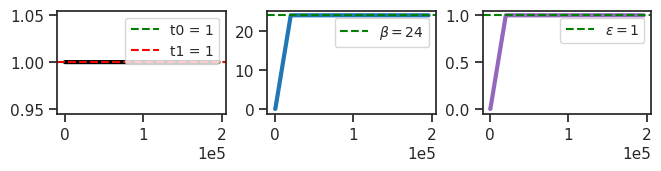

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
tr.n_iters

196000

In [6]:
print(tr.model.layer)
# print(tr.model.layer.n_exp)

GaussianSigmoidLayer(input_dim=256, latent_dim=768, temperature=1, beta_inner=1, eps=1)

In [7]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>),
 tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>))

In [8]:
vars(tr.model.cfg)

{'_type': 'gaussian',
 'latent_act': 'sigmoid',
 'seq_len': 16,
 'tbptt_steps': 16,
 'n_iters_inner': 1,
 'n_iters_outer': 1,
 'sequences': {0: range(0, 16)},
 'dataset': 'Kyoto16',
 'dataset_name': 'Kyoto16',
 'feeder': 'stationary',
 'feeder_cfg': {},
 'input_sz': (1, 16, 16),
 'shape': (-1, 1, 16, 16),
 'beta_inner': 1.0,
 'n_latents': [768],
 'inf_type': 'grad',
 'dec_type': 'lin',
 'clamp_u': 7.0,
 'clamp_du': 7.0,
 'init_dist': 'normal',
 'init_scale': 0.0001,
 'stochastic': True,
 'fit_prior': True,
 'track_stats': False,
 'seed': 0,
 'base_dir': '/home/hadi/Projects/PoissonVAE',
 'data_dir': '/home/hadi/Datasets',
 'runs_dir': '/home/hadi/Projects/PoissonVAE/runs/gaussian_sigmoid_Kyoto16_t-16_z-[768]_cl-7,7_<grad|lin>',
 'mods_dir': '/home/hadi/Projects/PoissonVAE/models/gaussian_sigmoid_Kyoto16_t-16_z-[768]_cl-7,7_<grad|lin>',
 'results_dir': '/home/hadi/Projects/PoissonVAE/results'}

In [9]:
print(inspect.getsource(tr.model.layer.grad_free_energy))

def grad_free_energy(self, x):
                # (1) recon
                grad_recon = self.grad_recon_term(x)
                eps = self.posterior.retrieve_noise(self.samples)
                # (2) kl
                grad_kl = self.grad_kl_term()
                # (3) compute sigma
                sigma = torch.exp(self.u[1])
                # (4) add up
                grad_mu = grad_recon + grad_kl[0].mul(self.beta_inner)
                grad_xi = (
                        grad_recon * eps * sigma
                        + grad_kl[1].mul(self.beta_inner)
                )
                # TODO: verify inverse Fisher calculations.
                # (5) inverse Fisher matrix
                grad_mu = grad_mu * sigma.pow(2)
                grad_xi = grad_xi * sigma.pow(4) * 2
                # (6) put together
                grad_f = (grad_mu + self.log_bias.exp(), grad_xi)
                return grad_f

In [10]:
cm = f"LatestCode+LargerLR+EfficGradReconImplem"
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 1000, avg loss: 199.232: 100%|████| 1000/1000 [2:26:51<00:00,  8.81s/it]


In [11]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0598], device='cuda:0', grad_fn=<ExpBackward0>),
 tensor([0.0257], device='cuda:0', grad_fn=<ExpBackward0>))

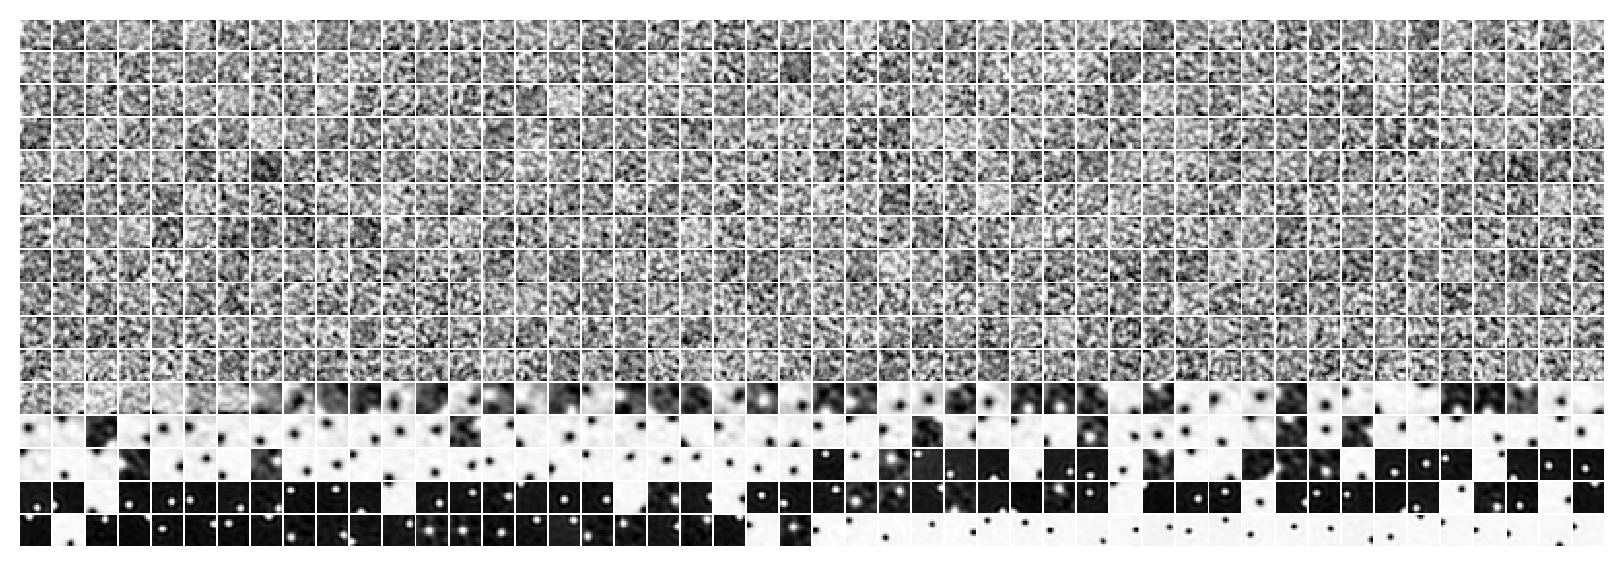

In [12]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16);

In [13]:
w = tr.model.layer.get_weight().T
absmax = torch.max(w.abs(), dim=1, keepdims=True).values

w_rescaled = 0.5 * (w / absmax + 1)
w_rescaled = w_rescaled.reshape(-1, 16, 16)

w_rescaled.shape

torch.Size([768, 16, 16])

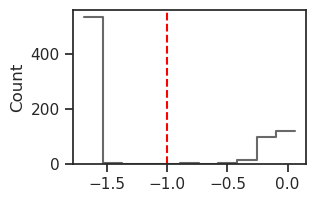

In [28]:
histplot(u0, color='dimgrey')
plt.axvline(-1.0, color='r', ls='--')
plt.show()

In [29]:
active = u0 > -1.0
active.sum()

233

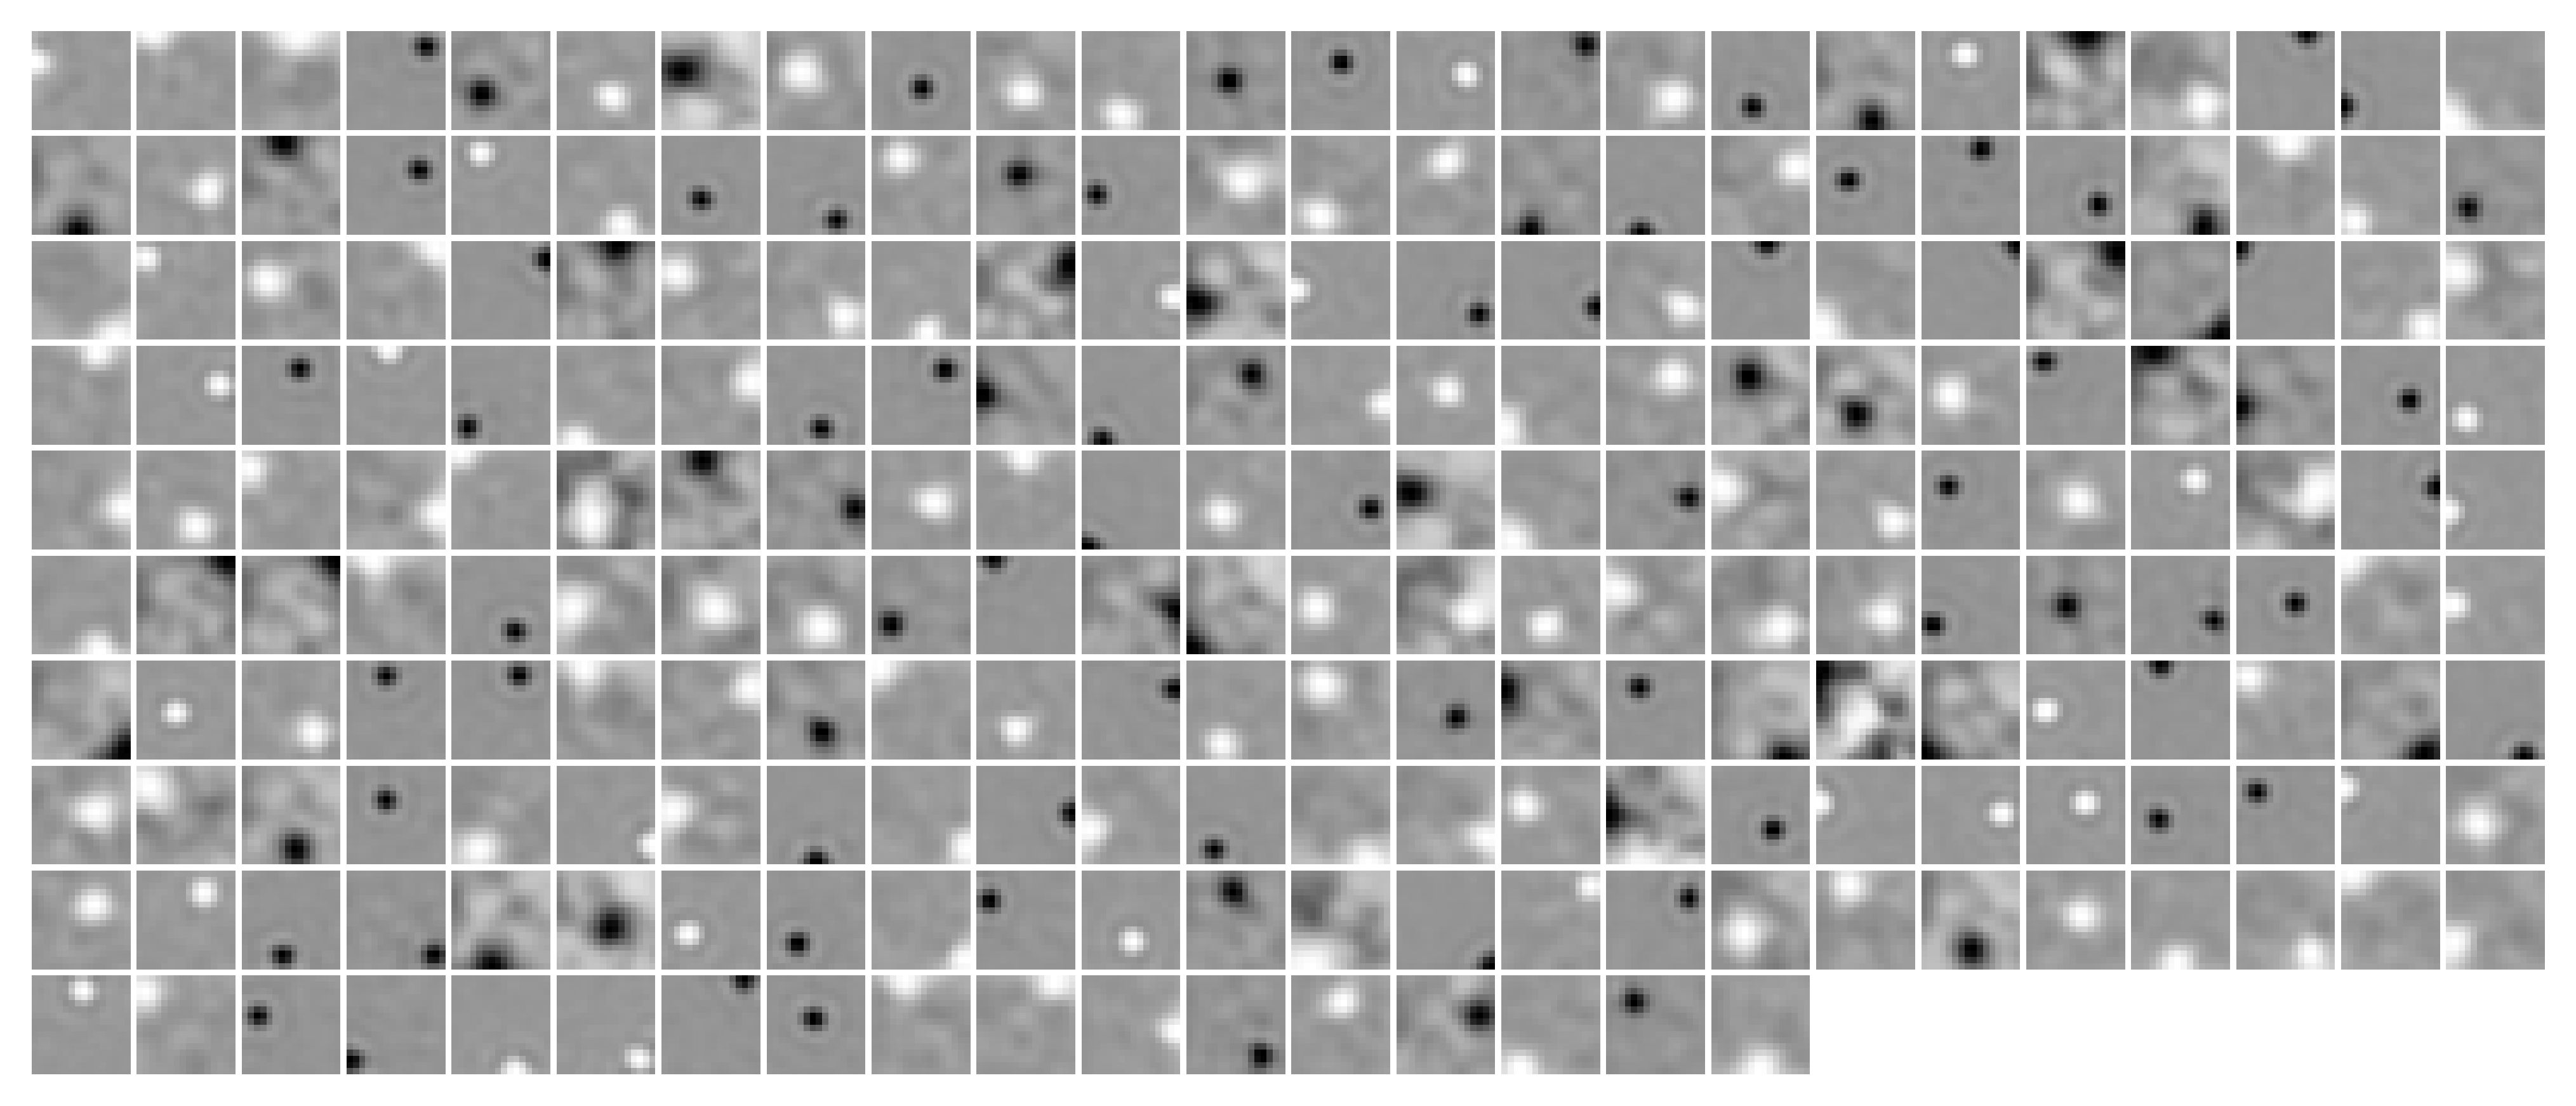

In [32]:
w_active = w_rescaled[active]

plot_weights(
    w=w_active,
    method='none',
    vmin=0,
    vmax=1,
    cmap='Greys',
    nrows=10,
    dpi=500,
);

In [34]:
bias = tonp(tr.model.layer.log_bias.squeeze().exp())
(bias < 0.2).sum()

233

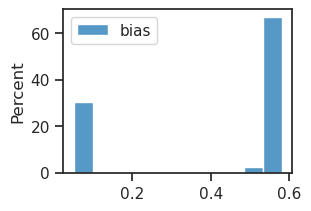

In [35]:
fig, ax = create_figure()

sns.histplot(bias, label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

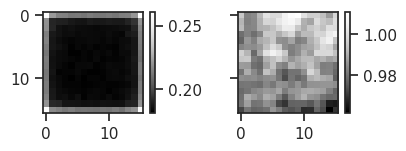

In [36]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 2/2 [00:31<00:00, 15.72s/it]


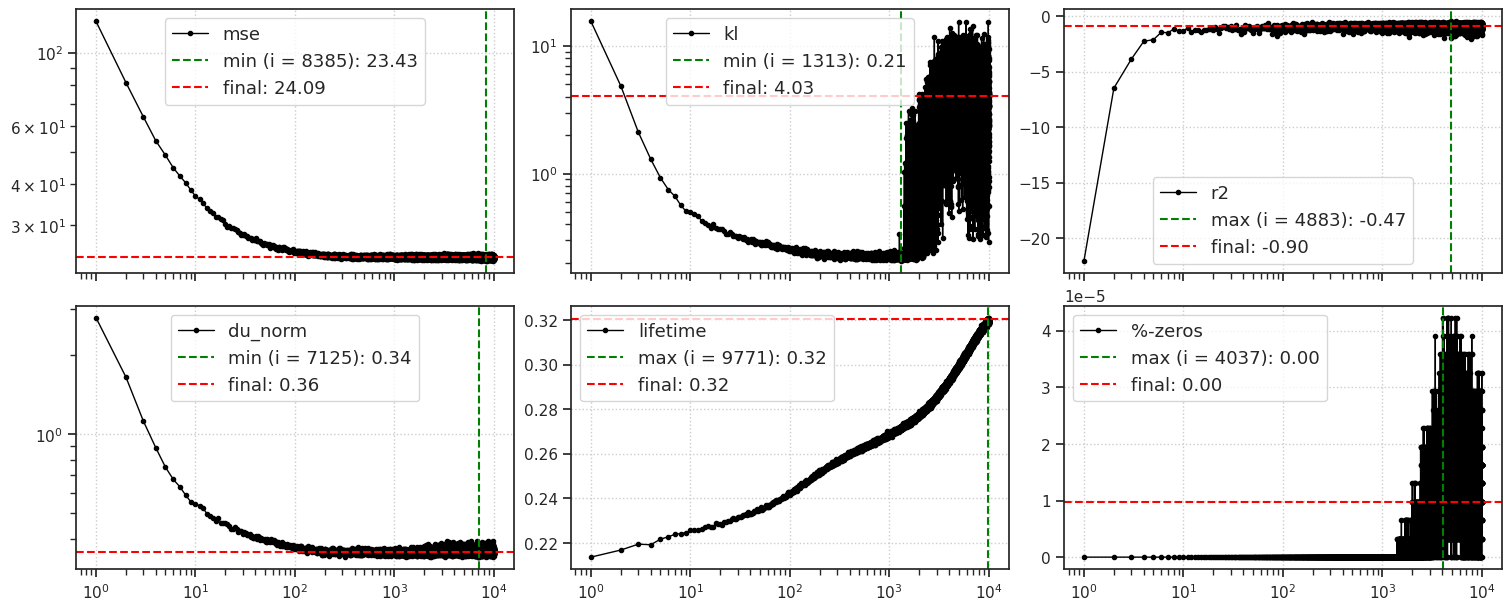

CPU times: user 45 s, sys: 4.16 s, total: 49.2 s
Wall time: 49.2 s


In [37]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

100%|███████████████████████████████████| 2/2 [00:35<00:00, 17.97s/it]


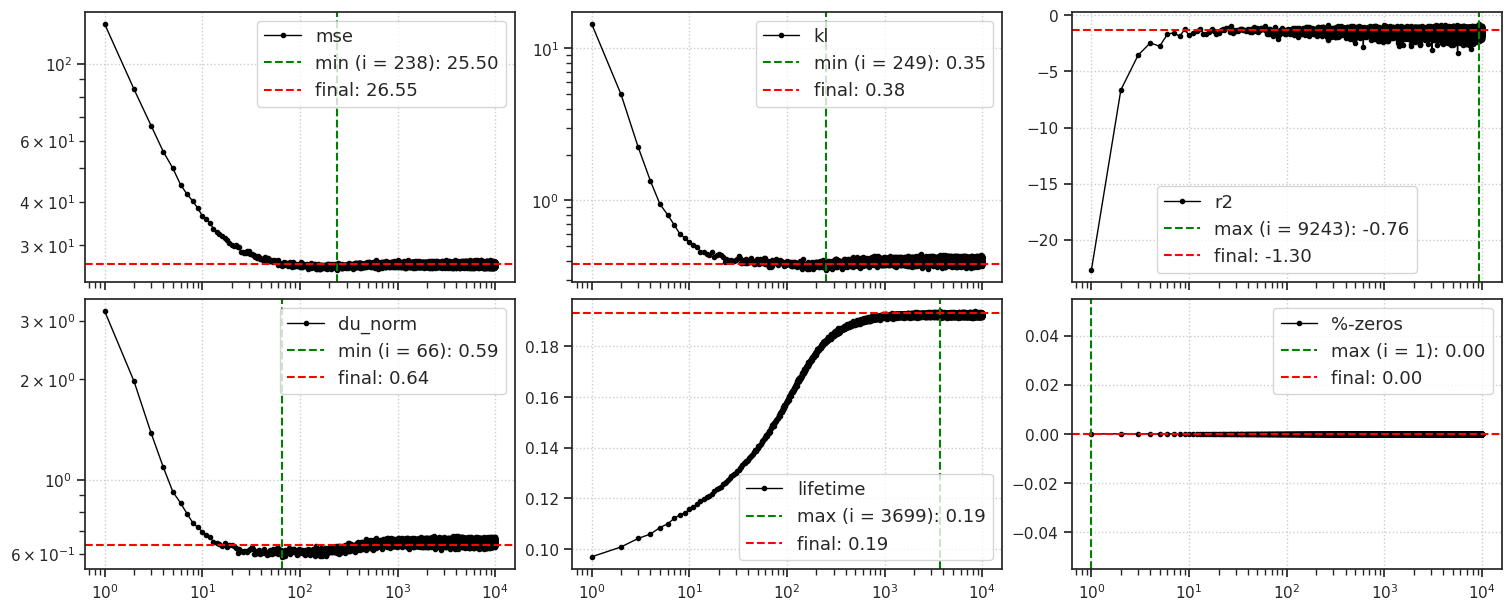

CPU times: user 46.8 s, sys: 3.54 s, total: 50.3 s
Wall time: 50.3 s


{'_type': 'gaussian',
 'latent_act': 'sigmoid',
 'seq_len': 16,
 'tbptt_steps': 16,
 'n_iters_inner': 1,
 'n_iters_outer': 1,
 'sequences': {0: range(0, 16)},
 'dataset': 'Kyoto16',
 'dataset_name': 'Kyoto16',
 'feeder': 'stationary',
 'feeder_cfg': {},
 'input_sz': (1, 16, 16),
 'shape': (-1, 1, 16, 16),
 'beta_inner': 1.0,
 'n_latents': [768],
 'inf_type': 'grad',
 'dec_type': 'lin',
 'clamp_u': 5.0,
 'clamp_du': 5.0,
 'init_dist': 'normal',
 'init_scale': 0.0001,
 'stochastic': True,
 'fit_prior': True,
 'track_stats': True,
 'seed': 0,
 'base_dir': '/home/hadi/Projects/PoissonVAE',
 'data_dir': '/home/hadi/Datasets',
 'runs_dir': '/home/hadi/Projects/PoissonVAE/runs/gaussian_sigmoid_Kyoto16_t-16_z-[768]_cl-5,5_<grad|lin>',
 'mods_dir': '/home/hadi/Projects/PoissonVAE/models/gaussian_sigmoid_Kyoto16_t-16_z-[768]_cl-5,5_<grad|lin>',
 'results_dir': '/home/hadi/Projects/PoissonVAE/results'}

def grad_free_energy(self, x):
                # (1) recon
                grad_recon = self.grad_recon_term(x)
                eps = self.posterior.retrieve_noise(self.samples)
                # (2) kl
                grad_kl = self.grad_kl_term()
                # (3) add up
                grad_mu = grad_recon + grad_kl[0].mul(self.beta_inner)
                grad_xi = (
                        grad_recon * eps * torch.exp(self.u[1])
                        + grad_kl[1].mul(self.beta_inner)
                )
                # TODO: verify inverse Fisher calculations.
                # (4) inverse Fisher matrix
                grad_mu = grad_mu * torch.exp(2 * self.u[1])
                grad_xi = grad_xi * torch.exp(4 * self.u[1]) * 2
                # (5) put together
                grad_f = (grad_mu + self.log_bias.exp(), grad_xi)
                return grad_f

epoch # 140, avg loss: 166.687784:  14%|▍  | 139/1000 [21:54<2:15:40,  9.46s/it]

epoch # 1000, avg loss: 200.909417: 100%|█| 1000/1000 [2:37:12<00:00,  9.43s/it]


In [9]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0627], device='cuda:0', grad_fn=<ExpBackward0>),
 tensor([0.0051], device='cuda:0', grad_fn=<ExpBackward0>))

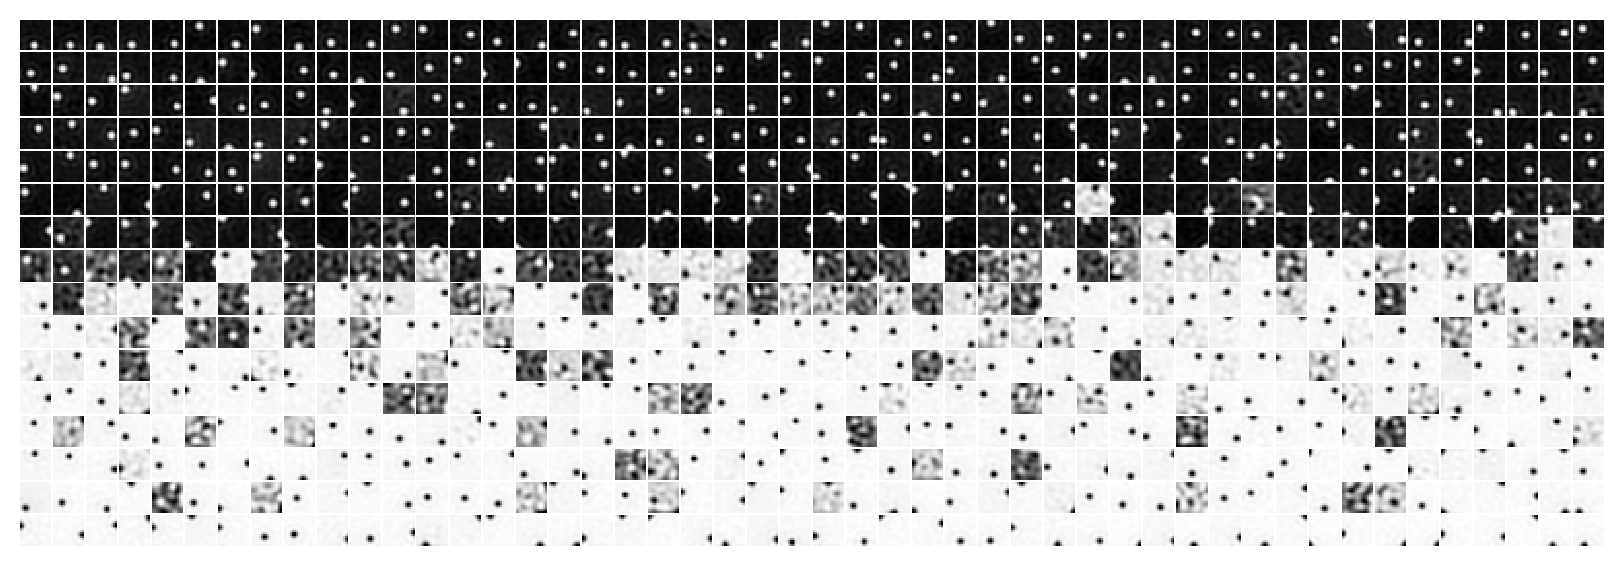

In [10]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16);

In [11]:
w = tr.model.layer.get_weight().T
absmax = torch.max(w.abs(), dim=1, keepdims=True).values

w_rescaled = 0.5 * (w / absmax + 1)
w_rescaled = w_rescaled.reshape(-1, 16, 16)

w_rescaled.shape

torch.Size([768, 16, 16])

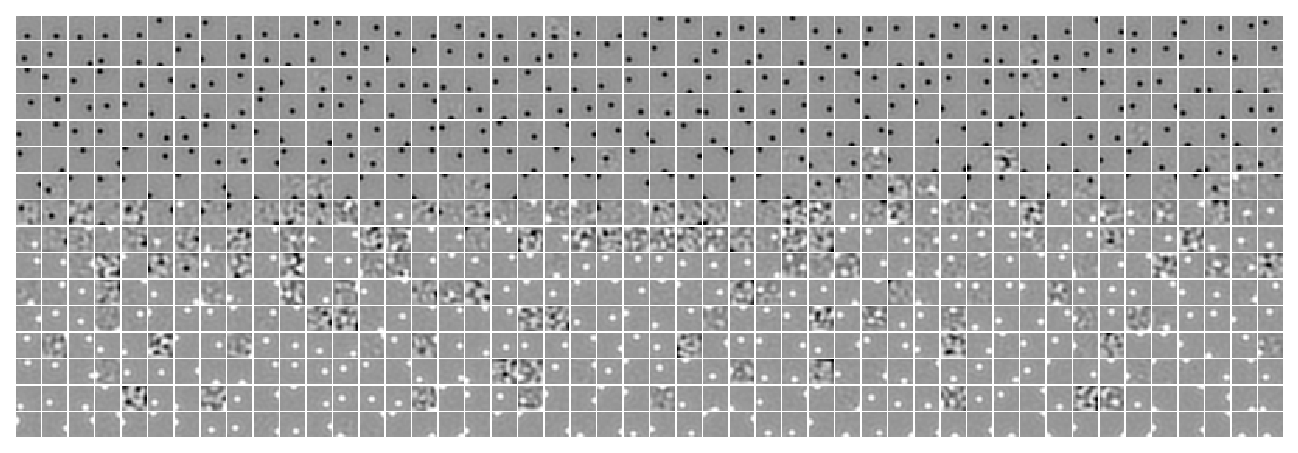

In [12]:
plot_weights(
    w=w_rescaled[np.argsort(u0)],
    method='none',
    vmin=0,
    vmax=1,
    cmap='Greys',
);

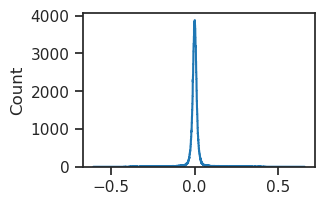

In [13]:
histplot(w.ravel())
plt.show()

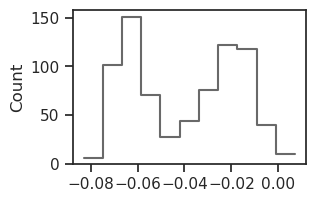

In [14]:
histplot(u0, color='dimgrey')
plt.show()

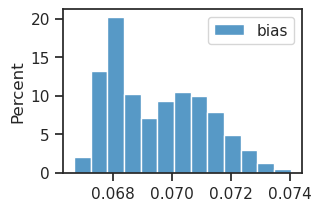

In [15]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

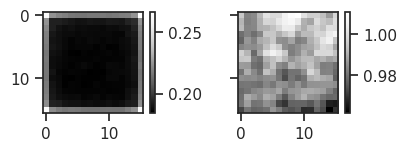

In [18]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 2/2 [00:35<00:00, 17.97s/it]


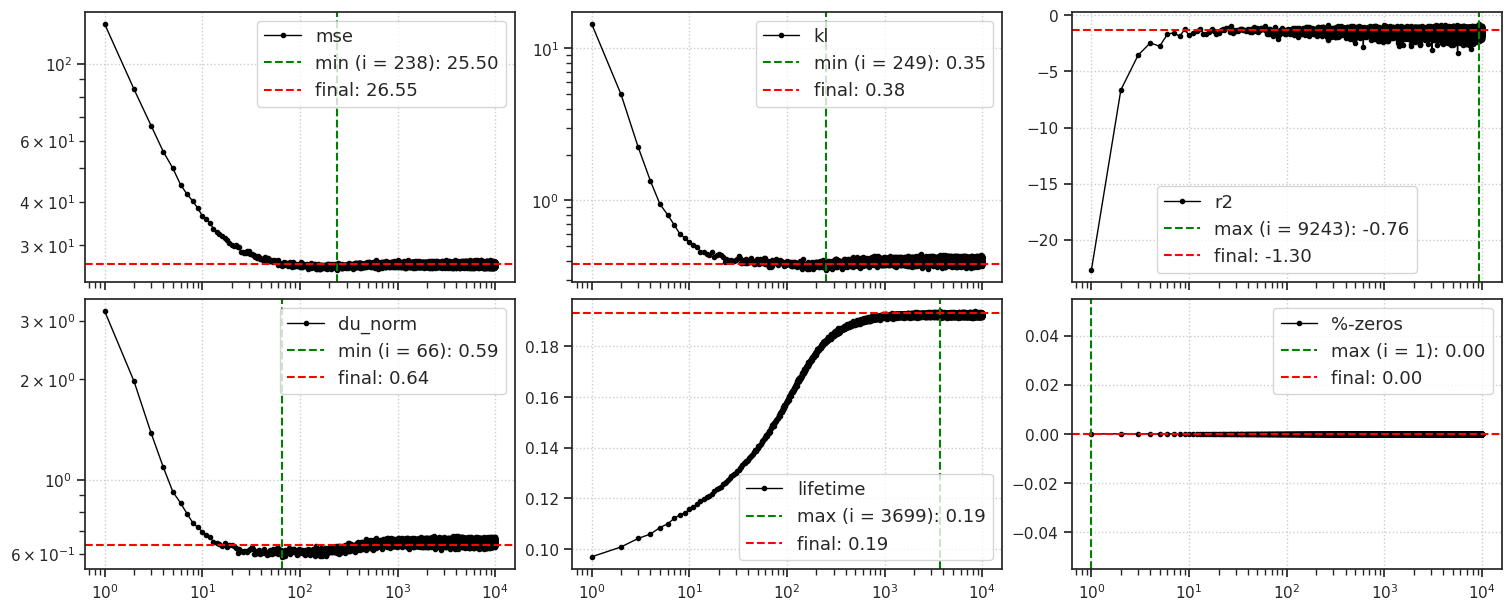

CPU times: user 46.8 s, sys: 3.54 s, total: 50.3 s
Wall time: 50.3 s


In [19]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

## output

In [20]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

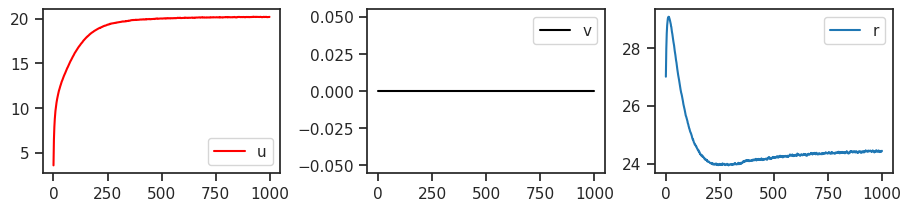

In [21]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

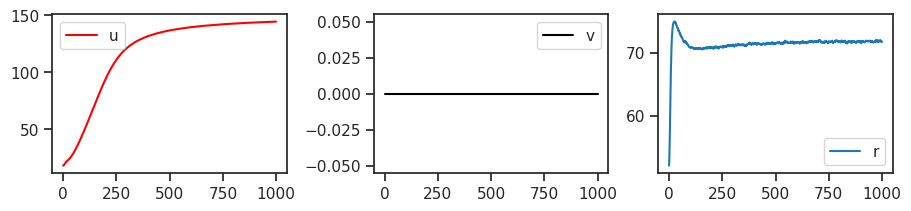

In [17]:
### Was: beta = 20.0

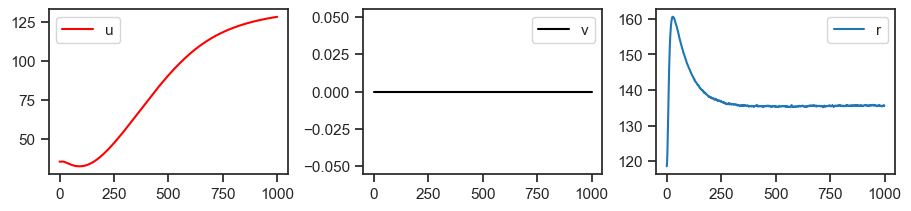

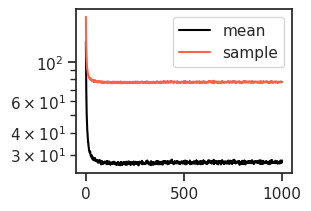

(tensor([27.3813, 27.3916, 27.0705, 27.1724, 27.8886], device='cuda:0'),
 tensor([77.5244, 77.2575, 76.9498, 76.8427, 77.4433], device='cuda:0'))

In [22]:
feeder = tr.get_feeder()

locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)

samples = torch.stack([
    p.sample() for p in
    output['conditional'].values()
], dim=1)

mse_locs = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
mse_samples = (samples - feeder[0].unsqueeze(1)).pow(2).sum(-1)

fig, ax = create_figure()
ax.plot(tonp(mse_locs.mean(0)), color='k', label='mean')
ax.plot(tonp(mse_samples.mean(0)), color='tomato', label='sample')
ax.set_yscale('log')
add_legend(ax)
plt.show()

mse_locs.mean(0)[-5:], mse_samples.mean(0)[-5:]

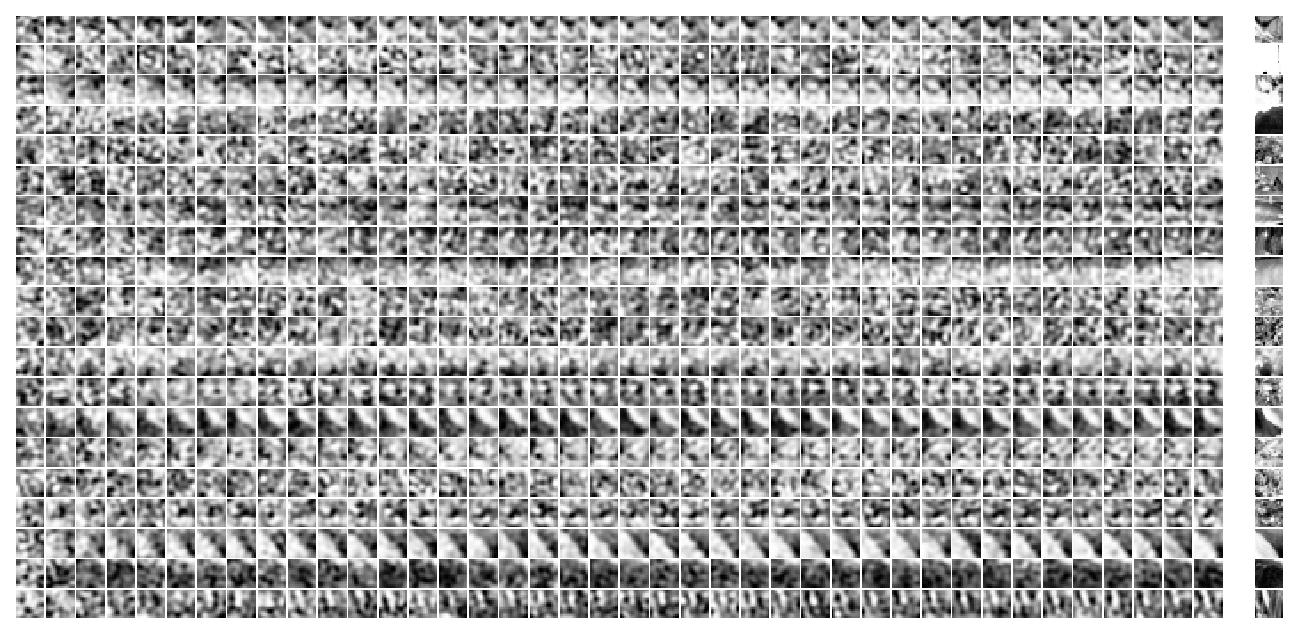

In [23]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

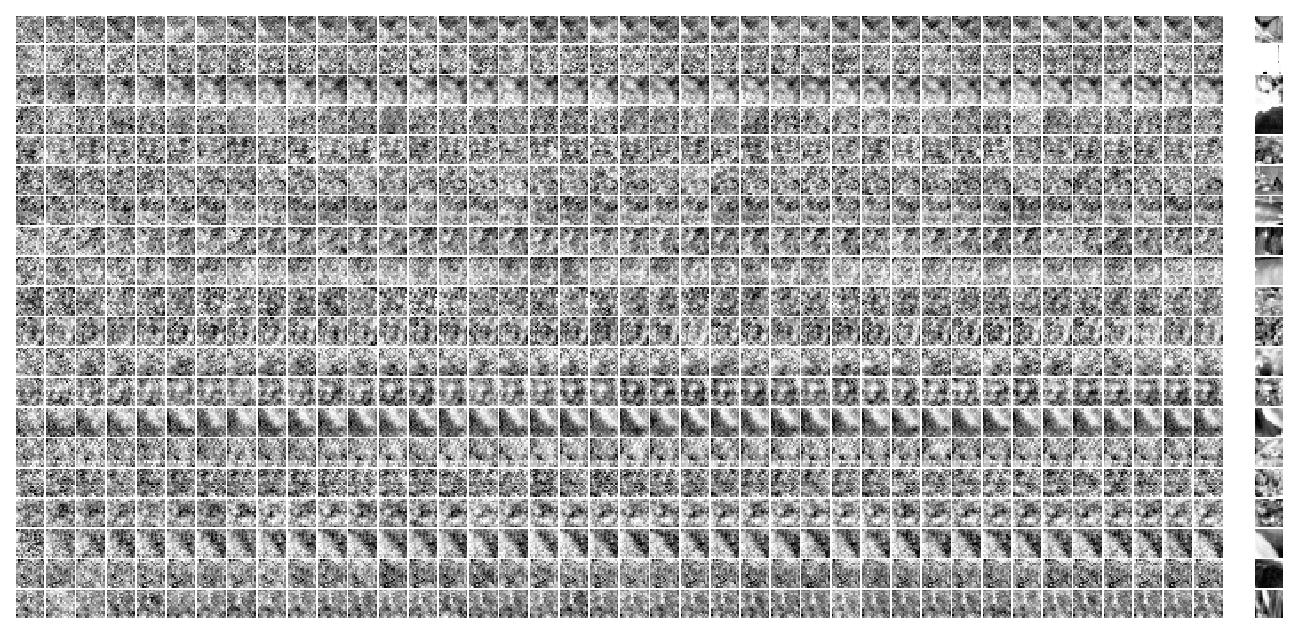

In [24]:
x2p = tonp(samples)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)